<a href="https://colab.research.google.com/github/positivefunctionIN/Plant_Leaf_Disease_Prediction_2.0/blob/main/Plant_Leaf_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np

print(tf.__version__)

2.20.0


In [2]:
!pip install -q kaggle

In [3]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_f8f365ac5c0ba445883f261d2f0f533d"

In [4]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:03<00:00, 199MB/s]



In [5]:
!unzip plantdisease.zip -d /content/plant_data

Streaming output truncated to the last 5000 lines.
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV

In [6]:
import os
print(os.listdir("/content/plant_data"))

['plantvillage', 'PlantVillage']


In [7]:
import os

print("plantvillage:", os.listdir("/content/plant_data/plantvillage")[:5])
print("PlantVillage:", os.listdir("/content/plant_data/PlantVillage")[:5])

plantvillage: ['PlantVillage']
PlantVillage: ['Tomato_healthy', 'Tomato_Early_blight', 'Potato___Early_blight', 'Tomato__Tomato_mosaic_virus', 'Potato___healthy']


In [8]:
dataset_path = "/content/plant_data/PlantVillage"

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,519,887 (24.87 MB)

 Trainable params: 6,519,887 (24.87 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    train_generator,
    validation_data = validation_generator,
    epochs = 10
)

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 36s 56ms/step - accuracy: 0.5561 - loss: 1.3775 - val_accuracy: 0.7710 - val_loss: 0.6957
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 25s 47ms/step - accuracy: 0.7484 - loss: 0.7598 - val_accuracy: 0.8401 - val_loss: 0.4723
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.8144 - loss: 0.5573 - val_accuracy: 0.8877 - val_loss: 0.3394
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.8482 - loss: 0.4587 - val_accuracy: 0.9059 - val_loss: 0.3007
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.8719 - loss: 0.3639 - val_accuracy: 0.8930 - val_loss: 0.3067
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.8920 - loss: 0.3179 - val_accuracy: 0.9110 - val_loss: 0.2744
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.9107 - loss: 0.2594 - val_accuracy: 0.9044 - val_loss: 0.2980
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.9229 - loss: 0.2285 - 

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

class_names = list(train_generator.class_indices.keys())
print(f"Class names: {class_names}")

def preprocess_image(image_path):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(128, 128))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array,axis = 0)
    img_array /= 255.0
    return img_array

def predict_image(image_path, model, class_name):
    processed_img = preprocess_image(image_path)
    predictions = model.predict(processed_img, verbose = 0)
    predicted_class_idx = np.argmax(predictions[0])
    predicted_class = class_names[predicted_class_idx]
    confidence = predictions[0][predicted_class_idx] * 100

    top_idx = np.argsort(predictions[0])[-3:][::-1]
    top3 = [(class_names[i], predictions[0][i] * 100) for i in top3_idx]


    return {
        "predicted_class": predicted_class,
        "confidence": confidence,
        "top3": top3,
        "all_probabilities": predictions[0]
    }

    def display_prediction(image_path, result):
        img = tf.keras.utils.load_img(image_path)

        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Predicted: {result['predicted_class']}\nConfidence: {result['confidence']:.2f}%")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        classes = [r[0] for r in result['top3']]
        confidences = [r[1] for r in result['top3']]
        short_classes = [c.split('___')[-1][:25] for c in classes]

        bars = plt.barh(short_classes, confidences, color='skyblue')
        bars[0].set_color('green')
        plt.xlabel('Confidence (%)')
        plt.title('Top 3 Predictions')

        plt.tight_layout()
        plt.show()

Class names: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


🌿 PLANT DISEASE PREDICTOR

📤 Step 1: Upload a plant leaf image


Saving fcc91cef-9892-4eb2-a3f0-36bdc4e11f59___JR_HL 7687.JPG to fcc91cef-9892-4eb2-a3f0-36bdc4e11f59___JR_HL 7687.JPG

🔍 Processing: fcc91cef-9892-4eb2-a3f0-36bdc4e11f59___JR_HL 7687.JPG


/tmp/ipykernel_538/3429787445.py:55: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_538/3429787445.py:55: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_538/3429787445.py:55: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_538/3429787445.py:55: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_538/3429787445.py:55: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missi

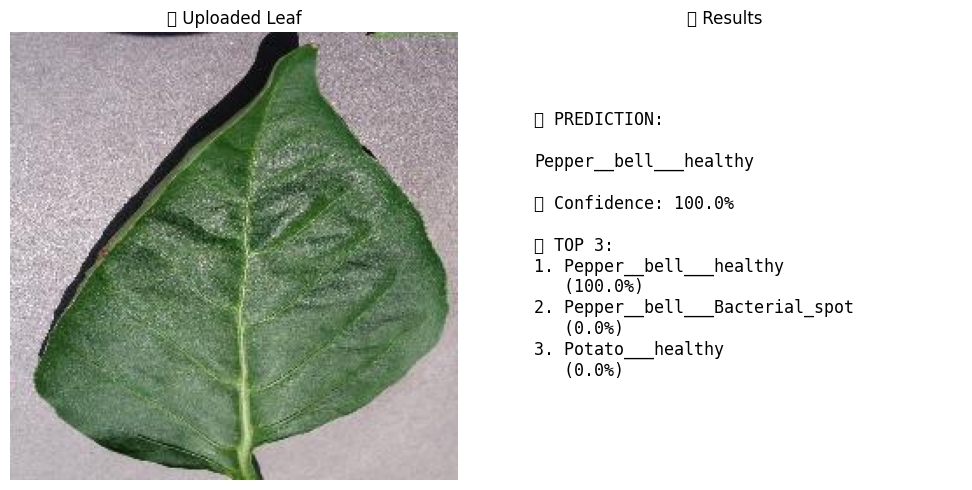


📊 RESULTS:
   ✅ Predicted: Pepper__bell___healthy
   📈 Confidence: 100.00%

   🏆 Top 3 predictions:
      1. Pepper__bell___healthy: 100.00%
      2. Pepper__bell___Bacterial_spot: 0.00%
      3. Potato___healthy: 0.00%


In [13]:
from google.colab import files
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("="*50)
print("🌿 PLANT DISEASE PREDICTOR")
print("="*50)

# Upload image
print("\n📤 Step 1: Upload a plant leaf image")
uploaded = files.upload()

# Class names (from your training)
class_names = list(train_generator.class_indices.keys())

# Process each uploaded image
for filename in uploaded.keys():
    print(f"\n🔍 Processing: {filename}")

    # Step 2: Load and preprocess image
    img = tf.keras.utils.load_img(filename, target_size=(128, 128))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Normalize

    # Step 3: Make prediction
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx] * 100

    # Get top 3 predictions
    top3_idx = np.argsort(predictions[0])[-3:][::-1]

    # Step 4: Display result
    plt.figure(figsize=(10, 5))

    # Show image
    plt.subplot(1, 2, 1)
    plt.imshow(tf.keras.utils.load_img(filename))
    plt.title(f"🌱 Uploaded Leaf", fontsize=12)
    plt.axis('off')

    # Show prediction text
    plt.subplot(1, 2, 2)
    plt.axis('off')
    result_text = f"✅ PREDICTION:\n\n{class_names[predicted_class_idx]}\n\n📊 Confidence: {confidence:.1f}%\n\n"
    result_text += f"🏆 TOP 3:\n"
    for i, idx in enumerate(top3_idx):
        result_text += f"{i+1}. {class_names[idx]}\n   ({predictions[0][idx]*100:.1f}%)\n"

    plt.text(0.1, 0.5, result_text, fontsize=12, verticalalignment='center', fontfamily='monospace')
    plt.title("📋 Results", fontsize=12)

    plt.tight_layout()
    plt.show()

    # Print to console
    print(f"\n📊 RESULTS:")
    print(f"   ✅ Predicted: {class_names[predicted_class_idx]}")
    print(f"   📈 Confidence: {confidence:.2f}%")
    print(f"\n   🏆 Top 3 predictions:")
    for i, idx in enumerate(top3_idx):
        print(f"      {i+1}. {class_names[idx]}: {predictions[0][idx]*100:.2f}%")

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import tensorflow as tf

print("="*50)
print("ALTERNATIVE GRAD-CAM (No model.output required)")
print("="*50)

# ============================================
# STEP 1: Get class names
# ============================================
class_names = list(train_generator.class_indices.keys())
print(f"✅ {len(class_names)} classes")

# ============================================
# STEP 2: Find the last conv layer in your ORIGINAL model
# ============================================
last_conv_layer = None
for layer in model.layers:
    if 'conv2d' in layer.name:
        last_conv_layer = layer.name
print(f"✅ Last conv layer in your model: {last_conv_layer}")

# ============================================
# STEP 3: Force model to build (original model)
# ============================================
print("\nForcing original model to build...")
try:
    dummy = tf.random.normal((1, 128, 128, 3))
    _ = model(dummy)
    print("✅ Model built")
except:
    print("⚠️ Model already built")

# ============================================
# STEP 4: Create a custom Grad-CAM function that doesn't use model.output
# ============================================
def get_gradcam_heatmap(image_path):
    """
    Generate Grad-CAM heatmap without creating a new Model object
    """
    # Load and preprocess image
    original_img = tf.keras.utils.load_img(image_path)
    img = tf.keras.utils.load_img(image_path, target_size=(128, 128))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # Get the last conv layer output by creating a temporary model
    # This is the key: we create a model that outputs ONLY the conv layer
    conv_layer_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=model.get_layer(last_conv_layer).output
    )

    # Get conv output
    conv_output = conv_layer_model(img_batch)

    # Get predictions using the original model
    predictions = model(img_batch)
    pred_idx = tf.argmax(predictions[0])
    confidence = tf.reduce_max(predictions[0]) * 100

    # Get the score for the predicted class
    score = predictions[:, pred_idx]

    # Calculate gradients
    with tf.GradientTape() as tape:
        # We need to watch the conv output
        tape.watch(conv_output)
        # Get predictions again (need to do this inside tape)
        preds = model(img_batch)
        loss = preds[:, pred_idx]

    # Get gradients of loss with respect to conv output
    grads = tape.gradient(loss, conv_output)

    # Average gradients spatially
    weights = tf.reduce_mean(grads, axis=(1, 2))

    # Weighted sum of conv output
    heatmap = tf.reduce_sum(tf.multiply(weights, conv_output), axis=-1)

    # Apply ReLU and normalize
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-10)

    heatmap = heatmap.numpy()[0]
    pred_class = class_names[pred_idx.numpy()]
    conf = confidence.numpy()

    # Create overlay
    img_cv = cv2.cvtColor(np.array(original_img), cv2.COLOR_RGB2BGR)
    img_cv = cv2.resize(img_cv, (128, 128))

    heatmap_resized = cv2.resize(heatmap, (128, 128))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB), 0.6, heatmap_colored, 0.4, 0)

    # Display
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(original_img)
    axes[0].set_title(f"Original\n{pred_class}\n{conf:.1f}%")
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title("Grad-CAM Heatmap\n(Red = Important)")
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay\n(Model focus area)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return pred_class, conf



ALTERNATIVE GRAD-CAM (No model.output required)
✅ 15 classes
✅ Last conv layer in your model: conv2d_2

Forcing original model to build...
✅ Model built


COMPLETE FIX: REBUILD MODEL + GRAD-CAM
✅ 15 classes

📦 Rebuilding model from scratch...

📋 Copying weights from trained model...
  ✅ Copied: conv2d_6
  ✅ Copied: max_pooling2d_6
  ✅ Copied: conv2d_7
  ✅ Copied: max_pooling2d_7
  ✅ Copied: conv2d_8
  ✅ Copied: max_pooling2d_8
  ✅ Copied: flatten_2
  ✅ Copied: dense_4
  ✅ Copied: dropout_2
  ✅ Copied: dense_5
✅ Weights copied successfully

🔍 Testing new model...
✅ New model works! Output shape: (1, 15)

✅ Last conv layer: conv2d_8

Testing Grad-CAM on a validation image
Testing on: 23a4712e-8805-43f7-9ae4-655d1c4799b0___RS_HL 0619.JPG


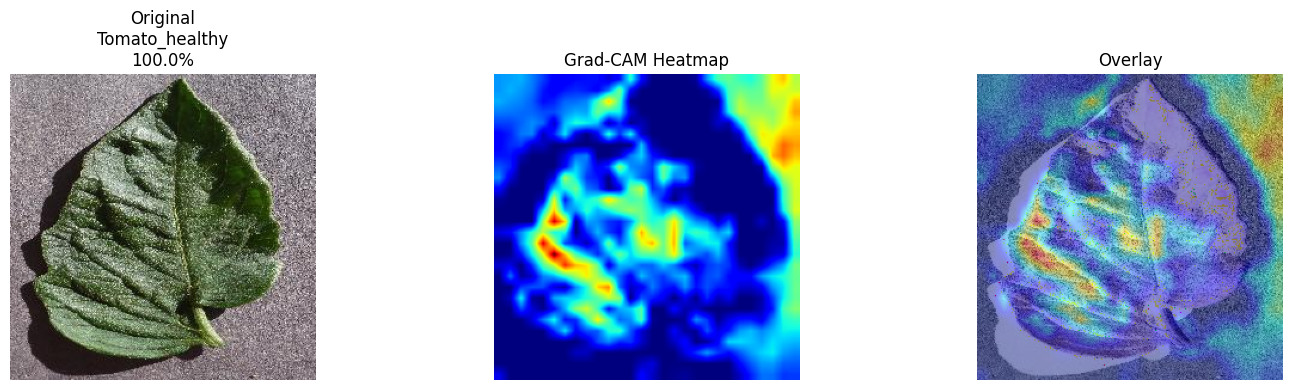

✅ Prediction: Tomato_healthy (100.0%)

Upload your leaf image


Saving e5d90520-de2e-4c6b-b73d-ca7f90c69772___NREC_B.Spot 1916.JPG to e5d90520-de2e-4c6b-b73d-ca7f90c69772___NREC_B.Spot 1916.JPG

🔍 Analyzing: e5d90520-de2e-4c6b-b73d-ca7f90c69772___NREC_B.Spot 1916.JPG


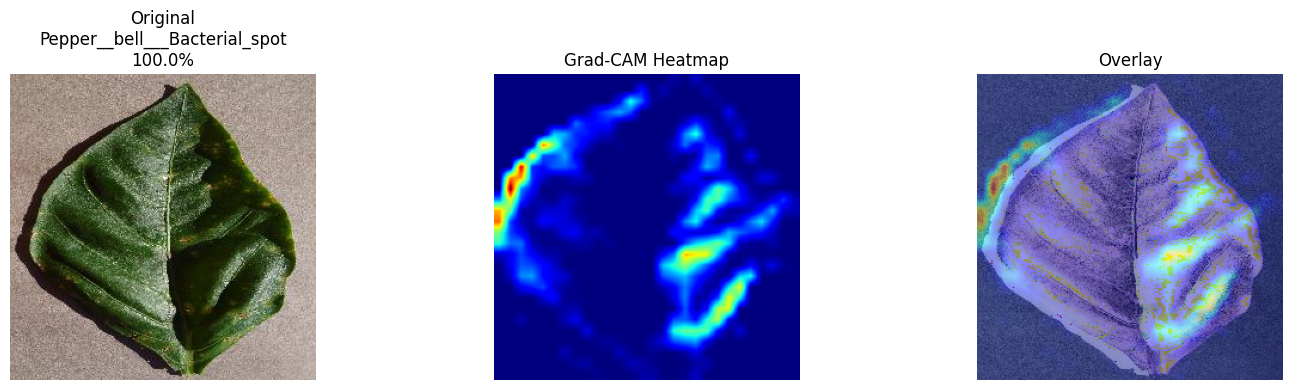

✅ Prediction: Pepper__bell___Bacterial_spot (100.0%)
🔴 Red regions = where the model focused


In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

print("="*60)
print("COMPLETE FIX: REBUILD MODEL + GRAD-CAM")
print("="*60)

# ============================================
# STEP 1: Get class names from your generator
# ============================================
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)
print(f"✅ {num_classes} classes")

# ============================================
# STEP 2: REBUILD your model from scratch (properly)
# ============================================
print("\n📦 Rebuilding model from scratch...")

new_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

# Compile
new_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ============================================
# STEP 3: Copy weights from your trained model
# ============================================
print("\n📋 Copying weights from trained model...")

# First, force both models to build
dummy = tf.random.normal((1, 128, 128, 3))
_ = model(dummy)  # Build original
_ = new_model(dummy)  # Build new

# Copy weights layer by layer
for i, layer in enumerate(new_model.layers):
    if i < len(model.layers):
        try:
            layer.set_weights(model.layers[i].get_weights())
            print(f"  ✅ Copied: {layer.name}")
        except Exception as e:
            print(f"  ⚠️ Skipped {layer.name}: {e}")

print("✅ Weights copied successfully")

# ============================================
# STEP 4: Verify the new model works
# ============================================
print("\n🔍 Testing new model...")
test_input = tf.random.normal((1, 128, 128, 3))
test_output = new_model(test_input)
print(f"✅ New model works! Output shape: {test_output.shape}")

# ============================================
# STEP 5: Find last conv layer in NEW model
# ============================================
last_conv_layer = None
for layer in new_model.layers:
    if 'conv2d' in layer.name:
        last_conv_layer = layer.name
print(f"\n✅ Last conv layer: {last_conv_layer}")

# ============================================
# STEP 6: Grad-CAM function using the NEW model
# ============================================
def grad_cam_working(image_path):
    # Load and preprocess
    original = plt.imread(image_path)
    img = tf.keras.utils.load_img(image_path, target_size=(128, 128))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_tensor = tf.convert_to_tensor(np.expand_dims(img_array, axis=0), dtype=tf.float32)

    # Get conv layer output and predictions
    with tf.GradientTape() as tape:
        # Forward pass through conv layers
        x = img_tensor
        for layer in new_model.layers:
            x = layer(x)
            if layer.name == last_conv_layer:
                conv_output = x
        predictions = x
        pred_class = tf.argmax(predictions[0])
        loss = predictions[0][pred_class]

    # Get gradients
    grads = tape.gradient(loss, conv_output)

    # Global average pooling
    weights = tf.reduce_mean(grads, axis=(1, 2))

    # Weighted sum
    heatmap = tf.reduce_sum(weights * conv_output, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-10)
    heatmap = heatmap.numpy()[0]

    # Resize and overlay
    heatmap_resized = cv2.resize(heatmap, (original.shape[1], original.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(np.uint8(original * 255), 0.6, heatmap_colored, 0.4, 0) / 255.0

    # Get prediction
    pred_idx = pred_class.numpy()
    confidence = predictions[0][pred_idx].numpy() * 100
    pred_name = class_names[pred_idx]

    # Display
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(original)
    axes[0].set_title(f"Original\n{pred_name}\n{confidence:.1f}%")
    axes[0].axis('off')
    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis('off')
    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()

    return pred_name, confidence

# ============================================
# STEP 7: Test on validation image first
# ============================================
print("\n" + "="*60)
print("Testing Grad-CAM on a validation image")
print("="*60)

test_path = None
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        files_list = os.listdir(folder_path)
        if len(files_list) > 0:
            test_path = os.path.join(folder_path, files_list[0])
            break

if test_path:
    print(f"Testing on: {os.path.basename(test_path)}")
    pred, conf = grad_cam_working(test_path)
    print(f"✅ Prediction: {pred} ({conf:.1f}%)")
else:
    print("No validation image found")

# ============================================
# STEP 8: Run on your image
# ============================================
print("\n" + "="*60)
print("Upload your leaf image")
print("="*60)

uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\n🔍 Analyzing: {filename}")
    pred, conf = grad_cam_working(filename)
    print(f"✅ Prediction: {pred} ({conf:.1f}%)")
    print("🔴 Red regions = where the model focused")